# Chapter 45 — Division-Aware Track Splitting

## Goal
Chapter 44 proved the rescued daughter detections survive re-tracking, but ordinary tracking attaches them to trajectories that begin before the GT division.

This chapter performs a **controlled GT-seeded topology experiment**:

1. Load Chapter 44 re-tracked nodes/edges.
2. Load the known GEFF division.
3. Re-identify the best Chapter 44 trajectory for each daughter.
4. Audit candidate split points at/after the division.
5. Cut each selected trajectory into a pre-division segment and a daughter segment.
6. Keep division relationships separate from ordinary continuation edges.
7. Compare topology before/after.
8. Save clean outputs for Chapter 46.

**Important:** GT seeds the split in this lesson. This is not yet inference-ready.

In [1]:
!pip install -q zarr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 89.5 MB/s eta 0:00:00


In [2]:
from pathlib import Path
from dataclasses import dataclass
import zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr
from IPython.display import display
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

## Step 1 — Configuration

In [3]:
@dataclass(frozen=True)
class Config:
    sample_id: str = "44b6_12dfb391"
    z_scale: float = 1.625
    y_scale: float = 0.40625
    x_scale: float = 0.40625
    division_daughter_t: int = 67
    split_search_start_t: int = 67
    split_search_end_t: int = 69
    useful_distance: float = 10.0

CONFIG = Config()
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(CONFIG)

Config(sample_id='44b6_12dfb391', z_scale=1.625, y_scale=0.40625, x_scale=0.40625, division_daughter_t=67, split_search_start_t=67, split_search_end_t=69, useful_distance=10.0)


## Step 2 — Locate Chapter 44 inputs

Attach your saved Chapter 44 outputs as a Kaggle dataset. The search is recursive so the dataset folder name does not have to be exactly `44data`.

In [4]:
def find_file(filename, required=False):
    roots = [Path("/kaggle/input"), Path("/kaggle/working")]
    matches = []
    for root in roots:
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            return direct
        try:
            matches.extend(root.rglob(filename))
        except Exception:
            pass
    if matches:
        return sorted(matches, key=lambda p: len(str(p)))[0]
    if required:
        raise FileNotFoundError(
            f"Could not find {filename}. Save/attach the Chapter 44 outputs first."
        )
    return None

paths = {
    "nodes": find_file("chapter44_retracked_track_nodes.csv", True),
    "edges": find_file("chapter44_retracked_track_edges.csv", True),
    "summary": find_file("chapter44_retracked_track_summary.csv"),
    "rescued_usage": find_file("chapter44_rescued_detection_usage.csv"),
}
print("="*80)
print("CHAPTER 45 INPUT CHECK")
print("="*80)
for k,v in paths.items():
    print(f"{k:18s}: {v if v else 'NOT FOUND (optional)'}")

CHAPTER 45 INPUT CHECK
nodes             : /kaggle/input/datasets/emailchrismathews/data44/chapter44_retracked_track_nodes.csv
edges             : /kaggle/input/datasets/emailchrismathews/data44/chapter44_retracked_track_edges.csv
summary           : /kaggle/input/datasets/emailchrismathews/data44/chapter44_retracked_track_summary.csv
rescued_usage     : NOT FOUND (optional)


## Step 3 — Load Chapter 44 tracks

In [5]:
nodes = pd.read_csv(paths["nodes"])
edges44 = pd.read_csv(paths["edges"])
nodes["t"] = nodes["t"].astype(int)
nodes["track_id"] = nodes["track_id"].astype(int)

def ensure_physical(df):
    out = df.copy()
    if "z_physical" not in out: out["z_physical"] = out["z"].astype(float)*CONFIG.z_scale
    if "y_physical" not in out: out["y_physical"] = out["y"].astype(float)*CONFIG.y_scale
    if "x_physical" not in out: out["x_physical"] = out["x"].astype(float)*CONFIG.x_scale
    return out

nodes = ensure_physical(nodes)
print("Nodes:", len(nodes))
print("Edges:", len(edges44))
print("Tracks:", nodes.track_id.nunique())
print("Frames:", nodes.t.min(), "to", nodes.t.max())
display(nodes.head())

Nodes: 5004
Edges: 4027
Tracks: 977
Frames: 0 to 99


,z,y,x,sigma,proposal_count,proposal_sources,proposal_peak_intensity,center_intensity,patch_mean,patch_max,patch_std,local_contrast,center_to_patch_max_dist,patch_com_offset,is_near_border,center_voxel,vol_mean,vol_std,vol_max,z_line_mean,z_line_std,z_line_max,center_over_vol_mean,center_minus_vol_mean,center_slice_minus_neighbor_mean,slice_mean_std,z_peak_offset,mass_center_offset_3d,peak_to_mean_ratio,bright_fraction,graph_neighbor_count,graph_mean_neighbor_distance,graph_min_neighbor_distance,graph_mean_neighbor_intensity,graph_mean_neighbor_contrast,graph_mean_neighbor_proposal_count,t,pred_dist,ranking_score,rank_position,detection_id,track_id,start_t,end_t,num_detections,duration,mean_rank,mean_pred_dist,path_length_physical,net_displacement_physical,track_path_efficiency,track_coverage_fraction,incoming_assignment_cost,incoming_frame_gap,outgoing_assignment_cost,outgoing_frame_gap,has_incoming_link,has_outgoing_link,two_sided_support,previous_step_length,next_step_length,previous_speed,next_speed,local_acceleration,direction_cosine,rank_quality,pred_dist_quality,track_length_quality,coverage_quality,path_efficiency_quality,link_cost_quality,step_quality,acceleration_quality,direction_quality,temporal_support_score,is_isolated,nearest_gt_dist,oracle_good,temporal_model_probability,final_filter_score,filtered_rank_position,z_physical,y_physical,x_physical
0,41,130,131,4.0,1,medium_strict,1754.0,1754.0,1583.678955,1790.0,139.085632,206.321045,1.000000,0.053404,0,1754.0,1588.271606,268.745636,2273.0,1818.000000,286.623810,2226.0,1.104345,165.728394,-19.833374,179.018341,1,0.156987,1.431115,0.432099,16.0,6.222860,1.625000,1660.5625,294.09106,1.7500,0,7.354238,-7.354238,1,chapter34_t0_0,0,0.0,8.0,6.0,9.0,104.500000,16.094382,57.053143,51.187500,0.897190,0.666667,NaN,NaN,3.509804,1.0,0.0,1.0,0.0,NaN,2.601269,NaN,2.601269,NaN,NaN,1.000000,0.840071,0.125,0.666667,0.897190,0.827170,0.674841,0.000000,0.000000,0.579070,0.0,3.316625,True,0.944917,0.798578,5.0,66.625,52.81250,53.21875
1,40,127,127,5.0,1,large_sensitive,1615.0,1615.0,1580.283936,1778.0,96.280228,197.716064,4.242641,0.070252,0,1615.0,1399.301270,270.528961,1940.0,1415.599976,270.030060,1648.0,1.154147,215.698730,123.962891,241.665009,1,0.205589,1.386406,0.550617,16.0,6.116712,1.284675,1648.8125,329.01083,1.3125,1,17.145113,-17.145113,67,chapter34_t1_66,0,0.0,8.0,6.0,9.0,104.500000,16.094382,57.053143,51.187500,0.897190,0.666667,3.509804,1.0,13.822260,2.0,1.0,1.0,1.0,2.601269,16.541910,2.601269,8.270955,5.977538,0.916671,0.668342,0.117756,0.125,0.666667,0.897190,0.567319,0.000000,0.003744,0.958336,0.435176,0.0,2.449490,True,0.789064,0.647509,18.0,65.000,51.59375,51.59375
2,41,121,125,2.5,1,small_sensitive,1645.0,1645.0,1525.987671,1785.0,253.272186,259.012329,3.162278,0.349888,0,1645.0,1340.708618,273.838715,1953.0,1422.599976,206.466064,1645.0,1.226963,304.291382,127.666626,150.779007,1,0.318561,1.456692,0.506173,16.0,5.773148,2.071477,1625.6250,280.61035,1.7500,4,17.487990,-17.487990,99,chapter34_t4_98,0,1.0,16.0,11.0,16.0,99.090909,17.317985,91.282532,45.300064,0.496262,0.687500,13.667094,3.0,11.876850,2.0,1.0,1.0,1.0,12.322172,9.020214,4.107391,4.510107,5.151621,0.288061,0.507538,0.092460,0.250,0.687500,0.496262,0.360398,0.000000,0.141397,0.644030,0.370031,0.0,4.242641,True,0.478982,0.435402,37.0,66.625,49.15625,50.78125
3,43,141,116,5.0,1,large_sensitive,1295.0,1295.0,1180.604980,1354.0,77.331207,173.395020,1.414214,0.054655,0,1295.0,1152.128418,206.863571,1620.0,1238.599976,153.680969,1409.0,1.124007,142.871582,-8.160400,118.445267,2,0.165548,1.406093,0.483951,16.0,5.937930,1.284675,1412.6875,239.54321,1.1250,5,13.398752,-13.398752,3,chapter34_t5_2,0,1.0,8.0,6.0,8.0,82.333333,16.141870,20.933268,18.348833,0.876539,0.750000,6.863287,2.0,4.390453,1.0,1.0,1.0,1.0,6.512683,2.071477,3.256341,2.071477,3.429145,0.232434,0.989950,0.394141,0.125,0.750000,0.876539,0.720479,0.463490,0.428476,0.616217,0.604273,0.0,27.531800,False,0.635629,0.623087,16.0,69.875,57.28125,47.1250

## Step 4 — Load the known GT division

In [6]:
def find_geff(sample_id):
    expected = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development/train") / f"{sample_id}.geff"
    if expected.exists():
        return expected
    matches = list(Path("/kaggle/input").rglob(f"{sample_id}.geff"))
    if not matches:
        raise FileNotFoundError(f"Could not find {sample_id}.geff")
    return sorted(matches, key=lambda p: len(str(p)))[0]

gp = find_geff(CONFIG.sample_id)
g = zarr.open(gp, mode="r")
gt_nodes = pd.DataFrame({
    "id": np.asarray(g["nodes/ids"][:]),
    "t": np.asarray(g["nodes/props/t/values"][:]).astype(int),
    "z": np.asarray(g["nodes/props/z/values"][:]).astype(float),
    "y": np.asarray(g["nodes/props/y/values"][:]).astype(float),
    "x": np.asarray(g["nodes/props/x/values"][:]).astype(float),
})
e = np.asarray(g["edges/ids"][:])
gt_edges = pd.DataFrame({"source":e[:,0], "target":e[:,1]})
od = gt_edges.groupby("source").size()
parents = od[od==2].index.tolist()
rows=[]
for pid in parents:
    kids=gt_edges.loc[gt_edges.source==pid,"target"].tolist()
    p=gt_nodes[gt_nodes.id==pid]
    a=gt_nodes[gt_nodes.id==kids[0]]
    b=gt_nodes[gt_nodes.id==kids[1]]
    if p.empty or a.empty or b.empty: continue
    p,a,b=p.iloc[0],a.iloc[0],b.iloc[0]
    rows.append({
        "gt_parent":pid,"gt_daughter_a":kids[0],"gt_daughter_b":kids[1],
        "parent_t":int(p.t),"daughter_t":min(int(a.t),int(b.t)),
        "parent_z":p.z,"parent_y":p.y,"parent_x":p.x,
        "daughter_a_z":a.z,"daughter_a_y":a.y,"daughter_a_x":a.x,
        "daughter_b_z":b.z,"daughter_b_y":b.y,"daughter_b_x":b.x,
    })
gt_divisions=pd.DataFrame(rows)
if gt_divisions.empty: raise RuntimeError("No GT division found.")
division=gt_divisions.iloc[0]
display(gt_divisions)

,gt_parent,gt_daughter_a,gt_daughter_b,parent_t,daughter_t,parent_z,parent_y,parent_x,daughter_a_z,daughter_a_y,daughter_a_x,daughter_b_z,daughter_b_y,daughter_b_x
0,172000000050,173000000050,173000000051,66,67,46.0,63.0,160.0,46.0,51.0,160.0,46.0,74.0,164.0


## Step 5 — Re-identify the best Chapter 44 daughter trajectories

In [7]:
def phys(z,y,x):
    return np.array([float(z)*CONFIG.z_scale,float(y)*CONFIG.y_scale,float(x)*CONFIG.x_scale])

targets={
    "daughter_a":phys(division.daughter_a_z,division.daughter_a_y,division.daughter_a_x),
    "daughter_b":phys(division.daughter_b_z,division.daughter_b_y,division.daughter_b_x),
}

selected_rows=[]
for role,target in targets.items():
    local=nodes[nodes.t.between(CONFIG.division_daughter_t, CONFIG.split_search_end_t)].copy()
    xyz=local[["z_physical","y_physical","x_physical"]].to_numpy(float)
    local["distance"]=np.linalg.norm(xyz-target[None,:],axis=1)
    best=local.sort_values("distance").iloc[0]
    tr=nodes[nodes.track_id==int(best.track_id)]
    selected_rows.append({
        "role":role,"track_id":int(best.track_id),"nearest_detection_id":best.detection_id,
        "nearest_t":int(best.t),"nearest_distance":float(best.distance),
        "track_start_t":int(tr.t.min()),"track_end_t":int(tr.t.max()),"track_length":len(tr)
    })
selected=pd.DataFrame(selected_rows)
display(selected)
print("Distinct source tracks:", selected.track_id.nunique())

,role,track_id,nearest_detection_id,nearest_t,nearest_distance,track_start_t,track_end_t,track_length
0,daughter_a,646,chapter34_t68_181,68,6.563170,64,68,5
1,daughter_b,573,chapter34_t68_101,68,6.749132,57,68,7


Distinct source tracks: 2


## Step 6 — Audit candidate split nodes

In [8]:
audit=[]
for s in selected.itertuples(index=False):
    tr=nodes[nodes.track_id==s.track_id].sort_values("t")
    cand=tr[tr.t.between(CONFIG.split_search_start_t,CONFIG.split_search_end_t)].copy()
    if cand.empty: cand=tr[tr.t>=CONFIG.division_daughter_t].copy()
    xyz=cand[["z_physical","y_physical","x_physical"]].to_numpy(float)
    cand["distance_to_gt_physical"]=np.linalg.norm(xyz-targets[s.role][None,:],axis=1)
    for r in cand.itertuples(index=False):
        audit.append({
            "role":s.role,"source_track_id":s.track_id,"detection_id":r.detection_id,
            "t":int(r.t),"z":float(r.z),"y":float(r.y),"x":float(r.x),
            "distance_to_gt_physical":float(r.distance_to_gt_physical)
        })
split_audit=pd.DataFrame(audit).sort_values(["role","distance_to_gt_physical"])
split_choices=split_audit.groupby("role",as_index=False).first()
split_choices["within_useful_distance"]=split_choices.distance_to_gt_physical<=CONFIG.useful_distance
print("Candidate audit:")
display(split_audit)
print("Chosen split anchors:")
display(split_choices)

Candidate audit:


,role,source_track_id,detection_id,t,z,y,x,distance_to_gt_physical
1,daughter_a,646,chapter34_t68_181,68,42.0,49.0,161.0,6.563170
0,daughter_a,646,chapter34_t67_191,67,40.0,46.0,158.0,9.992429
2,daughter_b,573,chapter34_t68_101,68,42.0,78.0,166.0,6.749132


Chosen split anchors:


,role,source_track_id,detection_id,t,z,y,x,distance_to_gt_physical,within_useful_distance
0,daughter_a,646,chapter34_t68_181,68,42.0,49.0,161.0,6.563170,True
1,daughter_b,573,chapter34_t68_101,68,42.0,78.0,166.0,6.749132,True


## Step 7 — Split the trajectories

The original trajectory keeps nodes before the chosen split time. Nodes from the split time onward receive a new daughter-track ID.

If both daughters unexpectedly map to the same source track, the notebook stops rather than silently producing an invalid branch.

In [9]:
if split_choices.source_track_id.nunique()!=2:
    raise RuntimeError(
        "Both daughters mapped to the same source track. This needs branch duplication, not a simple split."
    )

split_nodes=nodes.copy()
split_nodes["source_track_id_ch44"]=split_nodes.track_id.astype(int)
split_nodes["division_split_role"]=pd.NA
split_nodes["is_division_daughter_segment"]=False

next_id=int(split_nodes.track_id.max())+1
lineage=[]
mapping=[]

for c in split_choices.itertuples(index=False):
    source=int(c.source_track_id); split_t=int(c.t); new_id=next_id; next_id+=1
    mask=(split_nodes.track_id==source)&(split_nodes.t>=split_t)
    if not mask.any(): raise RuntimeError(f"No split rows for {c.role}")
    split_nodes.loc[mask,"track_id"]=new_id
    split_nodes.loc[mask,"division_split_role"]=c.role
    split_nodes.loc[mask,"is_division_daughter_segment"]=True
    parent_seg=split_nodes[split_nodes.track_id==source]
    daughter_seg=split_nodes[split_nodes.track_id==new_id]
    lineage.append({
        "event_id":f"gt_seeded_{c.role}",
        "event_type":"division_split",
        "role":c.role,
        "gt_parent_node_id":division.gt_parent,
        "gt_daughter_node_id":division.gt_daughter_a if c.role=="daughter_a" else division.gt_daughter_b,
        "source_track_id_ch44":source,
        "parent_segment_track_id":source,
        "daughter_track_id_ch45":new_id,
        "gt_parent_t":int(division.parent_t),"gt_daughter_t":int(division.daughter_t),
        "chosen_split_t":split_t,"chosen_split_detection_id":c.detection_id,
        "chosen_split_distance_physical":float(c.distance_to_gt_physical),
        "parent_segment_end_t":int(parent_seg.t.max()) if len(parent_seg) else np.nan,
        "daughter_segment_start_t":int(daughter_seg.t.min()),
        "daughter_segment_end_t":int(daughter_seg.t.max()),
        "daughter_segment_length":len(daughter_seg),
    })
    mapping.append({"role":c.role,"chapter44_track_id":source,"chapter45_daughter_track_id":new_id,"split_t":split_t})

lineage_events=pd.DataFrame(lineage)
track_mapping=pd.DataFrame(mapping)
split_nodes["track_id"]=split_nodes.track_id.astype(int)
split_nodes=split_nodes.sort_values(["track_id","t"]).reset_index(drop=True)
display(lineage_events)

,event_id,event_type,role,gt_parent_node_id,gt_daughter_node_id,source_track_id_ch44,parent_segment_track_id,daughter_track_id_ch45,gt_parent_t,gt_daughter_t,chosen_split_t,chosen_split_detection_id,chosen_split_distance_physical,parent_segment_end_t,daughter_segment_start_t,daughter_segment_end_t,daughter_segment_length
0,gt_seeded_daughter_a,division_split,daughter_a,1.720000e+11,1.730000e+11,646,646,977,66,67,68,chapter34_t68_181,6.563170,67,68,68,1
1,gt_seeded_daughter_b,division_split,daughter_b,1.720000e+11,1.730000e+11,573,573,978,66,67,68,chapter34_t68_101,6.749132,66,68,68,1


## Step 8 — Rebuild continuation edges

In [10]:
erows=[]
for tid,grp in split_nodes.groupby("track_id"):
    grp=grp.sort_values("t").reset_index(drop=True)
    for i in range(len(grp)-1):
        a,b=grp.iloc[i],grp.iloc[i+1]
        erows.append({
            "track_id":int(tid),"source_detection_id":a.detection_id,
            "target_detection_id":b.detection_id,"source_t":int(a.t),
            "target_t":int(b.t),"frame_gap":int(b.t-a.t),"edge_type":"continuation"
        })
split_edges=pd.DataFrame(erows)
print("Chapter 44 edges:",len(edges44))
print("Chapter 45 continuation edges:",len(split_edges))
print("Chapter 45 tracks:",split_nodes.track_id.nunique())

Chapter 44 edges: 4027
Chapter 45 continuation edges: 4025
Chapter 45 tracks: 979


## Step 9 — Before/after topology

In [11]:
compare=[]
for s in selected.itertuples(index=False):
    ev=lineage_events[lineage_events.role==s.role].iloc[0]
    tr=split_nodes[split_nodes.track_id==int(ev.daughter_track_id_ch45)].sort_values("t")
    xyz=tr[["z_physical","y_physical","x_physical"]].to_numpy(float)
    d=np.linalg.norm(xyz-targets[s.role][None,:],axis=1)
    j=int(np.argmin(d))
    compare.append({
        "role":s.role,
        "chapter44_track_id":s.track_id,
        "chapter44_track_start_t":s.track_start_t,
        "chapter44_best_distance":s.nearest_distance,
        "chapter44_started_before_division":s.track_start_t<CONFIG.division_daughter_t,
        "chapter45_daughter_track_id":int(ev.daughter_track_id_ch45),
        "chapter45_track_start_t":int(tr.t.min()),
        "chapter45_track_end_t":int(tr.t.max()),
        "chapter45_track_length":len(tr),
        "chapter45_best_distance":float(d[j]),
        "chapter45_nearest_t":int(tr.iloc[j].t),
        "chapter45_started_at_or_after_division":int(tr.t.min())>=CONFIG.division_daughter_t,
    })
before_after=pd.DataFrame(compare)
display(before_after)

,role,chapter44_track_id,chapter44_track_start_t,chapter44_best_distance,chapter44_started_before_division,chapter45_daughter_track_id,chapter45_track_start_t,chapter45_track_end_t,chapter45_track_length,chapter45_best_distance,chapter45_nearest_t,chapter45_started_at_or_after_division
0,daughter_a,646,64,6.563170,True,977,68,68,1,6.563170,68,True
1,daughter_b,573,57,6.749132,True,978,68,68,1,6.749132,68,True


## Step 10 — Visualize the split

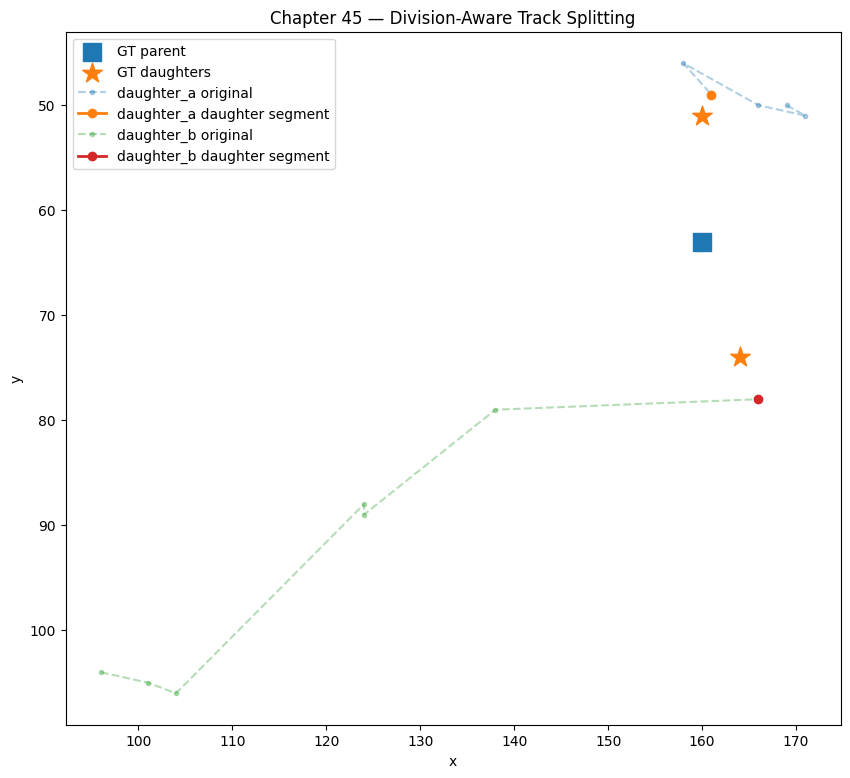

In [12]:
plt.figure(figsize=(10,9))
plt.scatter([division.parent_x],[division.parent_y],marker="s",s=150,label="GT parent")
plt.scatter([division.daughter_a_x,division.daughter_b_x],
            [division.daughter_a_y,division.daughter_b_y],marker="*",s=220,label="GT daughters")
for ev in lineage_events.itertuples(index=False):
    old=nodes[nodes.track_id==int(ev.source_track_id_ch44)].sort_values("t")
    new=split_nodes[split_nodes.track_id==int(ev.daughter_track_id_ch45)].sort_values("t")
    plt.plot(old.x,old.y,"--",marker=".",alpha=.35,label=f"{ev.role} original")
    plt.plot(new.x,new.y,marker="o",linewidth=2,label=f"{ev.role} daughter segment")
plt.gca().invert_yaxis()
plt.xlabel("x"); plt.ylabel("y")
plt.title("Chapter 45 — Division-Aware Track Splitting")
plt.legend(); plt.show()

## Step 11 — Build track summary and validate

In [13]:
srows=[]
for tid,gp in split_nodes.groupby("track_id"):
    gp=gp.sort_values("t")
    srows.append({
        "track_id":int(tid),"start_t":int(gp.t.min()),"end_t":int(gp.t.max()),
        "num_detections":len(gp),"duration":int(gp.t.max()-gp.t.min()+1),
        "coverage_fraction":len(gp)/max(int(gp.t.max()-gp.t.min()+1),1),
        "is_division_daughter_track":bool(gp.is_division_daughter_segment.any()),
        "division_role":gp.division_split_role.dropna().iloc[0] if gp.division_split_role.notna().any() else pd.NA,
        "source_track_id_ch44":int(gp.source_track_id_ch44.iloc[0])
    })
summary45=pd.DataFrame(srows)

validation=pd.DataFrame([
    {"check":"chapter44_nodes_loaded","passed":len(nodes)==5004,"details":f"{len(nodes)} nodes"},
    {"check":"two_distinct_daughter_sources","passed":selected.track_id.nunique()==2,"details":f"{selected.track_id.nunique()} source tracks"},
    {"check":"two_lineage_events","passed":len(lineage_events)==2,"details":f"{len(lineage_events)} events"},
    {"check":"node_count_preserved","passed":len(split_nodes)==len(nodes),"details":f"{len(split_nodes)} / {len(nodes)}"},
    {"check":"daughter_tracks_start_at_or_after_division","passed":bool(before_after.chapter45_started_at_or_after_division.all()),
     "details":str(before_after[["role","chapter45_track_start_t"]].to_dict("records"))},
    {"check":"daughter_tracks_remain_near_gt","passed":bool((before_after.chapter45_best_distance<=CONFIG.useful_distance).all()),
     "details":str(before_after[["role","chapter45_best_distance"]].to_dict("records"))},
])
display(validation)
print("Chapter 45 validation passed." if validation.passed.all() else "Review failed Chapter 45 checks.")

,check,passed,details
0,chapter44_nodes_loaded,True,5004 nodes
1,two_distinct_daughter_sources,True,2 source tracks
2,two_lineage_events,True,2 events
3,node_count_preserved,True,5004 / 5004
4,daughter_tracks_start_at_or_after_division,True,"[{'role': 'daughter_a', 'chapter45_track_start..."
5,daughter_tracks_remain_near_gt,True,"[{'role': 'daughter_a', 'chapter45_best_distan..."


Chapter 45 validation passed.


## Step 12 — Save outputs

In [14]:
outputs={
 "chapter45_division_split_track_nodes.csv":split_nodes,
 "chapter45_division_split_track_edges.csv":split_edges,
 "chapter45_division_split_track_summary.csv":summary45,
 "chapter45_lineage_events.csv":lineage_events,
 "chapter45_track_id_mapping.csv":track_mapping,
 "chapter45_split_candidate_audit.csv":split_audit,
 "chapter45_split_choices.csv":split_choices,
 "chapter45_before_after_topology.csv":before_after,
 "chapter45_gt_division.csv":gt_divisions,
 "chapter45_output_validation.csv":validation,
}
for name,df in outputs.items():
    p=OUTPUT_DIR/name
    df.to_csv(p,index=False)
    print(f"Saved {name}: {len(df):,} rows")

Saved chapter45_division_split_track_nodes.csv: 5,004 rows
Saved chapter45_division_split_track_edges.csv: 4,025 rows
Saved chapter45_division_split_track_summary.csv: 979 rows
Saved chapter45_lineage_events.csv: 2 rows
Saved chapter45_track_id_mapping.csv: 2 rows
Saved chapter45_split_candidate_audit.csv: 3 rows
Saved chapter45_split_choices.csv: 2 rows
Saved chapter45_before_after_topology.csv: 2 rows
Saved chapter45_gt_division.csv: 1 rows
Saved chapter45_output_validation.csv: 6 rows


## Step 13 — Safe ZIP

Only files beginning with `chapter45_` are packaged. We do **not** ZIP all of `/kaggle/working`, avoiding the disk-space failure encountered at the end of Chapter 43.

In [15]:
zip_path=OUTPUT_DIR/"chapter45_outputs.zip"
if zip_path.exists(): zip_path.unlink()
files=sorted([p for p in OUTPUT_DIR.glob("chapter45_*") if p.is_file() and p!=zip_path and p.suffix.lower()!=".zip"])
with zipfile.ZipFile(zip_path,"w",compression=zipfile.ZIP_DEFLATED,allowZip64=True) as zf:
    for p in files: zf.write(p,arcname=p.name)
verification=pd.DataFrame([{"filename":p.name,"size_bytes":p.stat().st_size,"exists":p.exists()} for p in files+[zip_path]])
print("Created:",zip_path)
print(f"ZIP size: {zip_path.stat().st_size/(1024**2):.3f} MB")
display(verification)

Created: /kaggle/working/chapter45_outputs.zip
ZIP size: 1.701 MB


,filename,size_bytes,exists
0,chapter45_before_after_topology.csv,444,True
1,chapter45_division_split_track_edges.csv,236346,True
2,chapter45_division_split_track_nodes.csv,4885760,True
3,chapter45_division_split_track_summary.csv,33230,True
4,chapter45_gt_division.csv,256,True
5,chapter45_lineage_events.csv,612,True
6,chapter45_output_validation.csv,522,True
7,chapter45_split_candidate_audit.csv,276,True
8,chapter45_split_choices.csv,239,True
9,chapter45_track_id_mapping.csv,104,True


# Chapter 45 Complete

The main result is `chapter45_before_after_topology.csv`.

Success means the close rescued detections are retained while their new daughter segments start at/after the division instead of inheriting the old pre-division track history.

### Next: Chapter 46 — Build GT-Seeded Division Training Examples from Split Tracks

Chapter 46 can use these corrected daughter segments to create positive parent/daughter triplets and hard negatives—the supervised dataset that Chapters 40–41 could not build.